In [13]:
# ============================================================
# BLOQUE 0 — PAQUETES
# ============================================================

paquetes <- c(
  "stringr",
  "stars",
  "sf",
  "readxl",
  "dplyr",
  "ggplot2",
  "viridis",
  "knitr"
)

instalar <- paquetes[!sapply(paquetes, requireNamespace, quietly = TRUE)]

if (length(instalar) > 0) {
  install.packages(instalar)
}

invisible(lapply(paquetes, library, character.only = TRUE))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: viridisLite



In [14]:
# ============================================================
# BLOQUE 1 — DESCARGAR DATOS BASE DEL CUBO RASTER/VECTOR
# ============================================================

getwd()

dir.create("data_heavy", showWarnings = FALSE)

myurl <- "http://geocorp.co/wind/wind_result.zip"
filename <- "wind_result.zip"

if (!file.exists(filename)) {
  download.file(myurl, filename, mode = "wb")
}

# Extraer dentro de data_heavy
unzip(filename, exdir = "./data_heavy/", overwrite = TRUE)

# Verificar qué quedó
list.files("./data_heavy/")

[1] "/home/rstudio/work/PRACTICA_7"

[1] "10fg_2017_2018.zip"            "download5Dcolombia.nc"        
 [3] "download5Dcolombia.zip"        "era5_bogota_t2m_2020_01.nc"   
 [5] "era5_land_meta_t2m_2024_01.nc" "goodland_10u_1.nc"            
 [7] "mi_zona_procesada.nc"          "MUNICIPIOS_WGS84.dbf"         
 [9] "MUNICIPIOS_WGS84.prj"          "MUNICIPIOS_WGS84.sbn"         
[11] "MUNICIPIOS_WGS84.sbx"          "MUNICIPIOS_WGS84.shp"         
[13] "MUNICIPIOS_WGS84.shp.xml"      "MUNICIPIOS_WGS84.shx"         
[15] "st1_cellindexlr.tif"           "st10_station.tif"             
[17] "st11_nh_10.tif"                "st12_nh_20.tif"               
[19] "st13_nh_50.tif"                "st14_nh_100.tif"              
[21] "st15_nh_250.tif"               "st16_nh_500.tif"              
[23] "st17_nh_700.tif"               "st18_nh_1000.tif"             
[25] "st19_nh_1700.tif"              "st2_lonindex.tif"             
[27] "st20_nh_3000.tif"              "st21_nh_7000.tif"             
[29] "st22_h_10.tif"                 "st23_h_20.tif"                
[31] "st24_h_50.tif"                 "st25_h_100.tif"               
[33] "st26_h_250.tif"                "st27_h_500.tif"               
[35] "st28_h_700.tif"                "st29_h_1000.tif"              
[37] "st3_latindex.tif"              "st30_h_1700.tif"              
[39] "st31_h_3000.tif"               "st32_h_7000.tif"              
[41] "st33_c_10.tif"                 "st34_c_20.tif"                
[43] "st35_c_50.tif"                 "st36_c_100.tif"               
[45] "st37_c_250.tif"                "st38_c_500.tif"               
[47] "st39_c_700.tif"                "st4_cellindextb.tif"          
[49] "st40_c_1000.tif"               "st41_c_1700.tif"              
[51] "st42_c_3000.tif"               "st43_c_7000.tif"              
[53] "st5_id.tif"                    "st6_nh_thresh.tif"            
[55] "st7_nh_mu_location.tif"        "st8_nh_psi_scale.tif"         
[57] "st9_distance_w.tif"            "t_diaria_bogota_9377.nc"

In [15]:
# ============================================================
# BLOQUE 2 — BUSCAR Y ORDENAR LOS ARCHIVOS TIF
# ============================================================

the_path <- "./"

rasterfiles <- list.files(
  path = the_path,
  pattern = "^st[0-9]+_.*\\.tif$",
  full.names = TRUE,
  recursive = TRUE
)

# Evitar mezclar archivos de hazard_curves si luego aparecen duplicados
rasterfiles <- rasterfiles[
  !grepl("hazard_curves", rasterfiles)
]

rasterfiles <- stringr::str_sort(rasterfiles, numeric = TRUE)

head(rasterfiles)
tail(rasterfiles)
length(rasterfiles)

[1] ".//data_heavy/st1_cellindexlr.tif" ".//data_heavy/st2_lonindex.tif"   
[3] ".//data_heavy/st3_latindex.tif"    ".//data_heavy/st4_cellindextb.tif"
[5] ".//data_heavy/st5_id.tif"          ".//data_heavy/st6_nh_thresh.tif"

[1] ".//st38_c_500.tif"  ".//st39_c_700.tif"  ".//st40_c_1000.tif"
[4] ".//st41_c_1700.tif" ".//st42_c_3000.tif" ".//st43_c_7000.tif"

[1] 86

In [16]:
# ============================================================
# BLOQUE 3 — CREAR CUBO STARS DESDE LOS TIF
# ============================================================

h_nh_c.st <- read_stars(rasterfiles, quiet = TRUE)

mynames <- names(h_nh_c.st)

head(mynames)
tail(mynames)

# Limpiar nombres:
# De "1_cellindexlr.tif" a "cellindexlr"
mynames <- str_replace(mynames, "^\\d+_", "")
mynames <- str_replace(mynames, "\\.tif$", "")

h_nh_c.st <- setNames(h_nh_c.st, mynames)

h_nh_c.st

names(h_nh_c.st)

[1] "data_heavy/st1_cellindexlr.tif" "data_heavy/st2_lonindex.tif"   
[3] "data_heavy/st3_latindex.tif"    "data_heavy/st4_cellindextb.tif"
[5] "data_heavy/st5_id.tif"          "data_heavy/st6_nh_thresh.tif"

[1] "st38_c_500.tif"  "st39_c_700.tif"  "st40_c_1000.tif" "st41_c_1700.tif"
[5] "st42_c_3000.tif" "st43_c_7000.tif"

stars object with 2 dimensions and 86 attributes
attribute(s):
                                     Min.     1st Qu.      Median        Mean
data_heavy/st1_cellindexlr      1.0000000 846.0000000 1691.000000 1691.000000
data_heavy/st2_lonindex         1.0000000  13.0000000   25.000000   25.000000
data_heavy/st3_latindex         1.0000000  18.0000000   35.000000   35.000000
data_heavy/st4_cellindextb      1.0000000 846.0000000 1691.000000 1691.000000
data_heavy/st5_id               1.0000000 846.0000000 1691.000000 1691.000000
data_heavy/st6_nh_thresh       24.0000000  37.0000000   42.000000   43.958296
data_heavy/st7_nh_mu_location  13.6729488  24.5889168   28.071484   30.972949
data_heavy/st8_nh_psi_scale     0.8468198   2.4524689    2.949068    3.047828
data_heavy/st9_distance_w       0.2110516   0.8411635    1.240552    1.308701
data_heavy/st10_station         1.0000000 846.0000000 1691.000000 1691.000000
data_heavy/st11_nh_10          30.4555740  47.2962570   54.978470   56.002591
d

[1] "data_heavy/st1_cellindexlr"    "data_heavy/st2_lonindex"      
 [3] "data_heavy/st3_latindex"       "data_heavy/st4_cellindextb"   
 [5] "data_heavy/st5_id"             "data_heavy/st6_nh_thresh"     
 [7] "data_heavy/st7_nh_mu_location" "data_heavy/st8_nh_psi_scale"  
 [9] "data_heavy/st9_distance_w"     "data_heavy/st10_station"      
[11] "data_heavy/st11_nh_10"         "data_heavy/st12_nh_20"        
[13] "data_heavy/st13_nh_50"         "data_heavy/st14_nh_100"       
[15] "data_heavy/st15_nh_250"        "data_heavy/st16_nh_500"       
[17] "data_heavy/st17_nh_700"        "data_heavy/st18_nh_1000"      
[19] "data_heavy/st19_nh_1700"       "data_heavy/st20_nh_3000"      
[21] "data_heavy/st21_nh_7000"       "data_heavy/st22_h_10"         
[23] "data_heavy/st23_h_20"          "data_heavy/st24_h_50"         
[25] "data_heavy/st25_h_100"         "data_heavy/st26_h_250"        
[27] "data_heavy/st27_h_500"         "data_heavy/st28_h_700"        
[29] "data_heavy/st29_h_1000"        "data_heavy/st30_h_1700"       
[31] "data_heavy/st31_h_3000"        "data_heavy/st32_h_7000"       
[33] "data_heavy/st33_c_10"          "data_heavy/st34_c_20"         
[35] "data_heavy/st35_c_50"          "data_heavy/st36_c_100"        
[37] "data_heavy/st37_c_250"         "data_heavy/st38_c_500"        
[39] "data_heavy/st39_c_700"         "data_heavy/st40_c_1000"       
[41] "data_heavy/st41_c_1700"        "data_heavy/st42_c_3000"       
[43] "data_heavy/st43_c_7000"        "st1_cellindexlr"              
[45] "st2_lonindex"                  "st3_latindex"                 
[47] "st4_cellindextb"               "st5_id"                       
[49] "st6_nh_thresh"                 "st7_nh_mu_location"           
[51] "st8_nh_psi_scale"              "st9_distance_w"               
[53] "st10_station"                  "st11_nh_10"                   
[55] "st12_nh_20"                    "st13_nh_50"                   
[57] "st14_nh_100"                   "st15_nh_250"                  
[59] "st16_nh_500"                   "st17_nh_700"                  
[61] "st18_nh_1000"                  "st19_nh_1700"                 
[63] "st20_nh_3000"                  "st21_nh_7000"                 
[65] "st22_h_10"                     "st23_h_20"                    
[67] "st24_h_50"                     "st25_h_100"                   
[69] "st26_h_250"                    "st27_h_500"                   
[71] "st28_h_700"                    "st29_h_1000"                  
[73] "st30_h_1700"                   "st31_h_3000"                  
[75] "st32_h_7000"                   "st33_c_10"                    
[77] "st34_c_20"                     "st35_c_50"                    
[79] "st36_c_100"                    "st37_c_250"                   
[81] "st38_c_500"                    "st39_c_700"                   
[83] "st40_c_1000"                   "st41_c_1700"                  
[85] "st42_c_3000"                   "st43_c_7000"

In [17]:
# ============================================================
# BLOQUE 4 — CONVERTIR RASTER A POLÍGONOS Y GRAFICAR C_700
# ============================================================

h_nh_c.stnoxy <- st_xy2sfc(
  h_nh_c.st,
  as_points = FALSE,
  na.rm = TRUE
)

# Buscar municipios
mun_path <- list.files(
  ".",
  pattern = "MUNICIPIOS_WGS84\\.shp$",
  full.names = TRUE,
  recursive = TRUE
)

mun_path

mun <- st_read(mun_path[1])

plot(h_nh_c.stnoxy["c_700"], reset = FALSE, border = NA)
plot(st_geometry(mun), add = TRUE)

[1] "./data_heavy/MUNICIPIOS_WGS84.shp" "./MUNICIPIOS_WGS84.shp"

Reading layer `MUNICIPIOS_WGS84' from data source 
  `/home/rstudio/work/PRACTICA_7/data_heavy/MUNICIPIOS_WGS84.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1126 features and 3 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -79.0369 ymin: -4.228051 xmax: -66.84933 ymax: 12.45824
Geodetic CRS:  WGS 84


Warning message in structure(eval(rlang::expr(x[[i]][!!!args])), levels = attr(x[[i]], :
“Calling 'structure(NULL, *)' is deprecated, as NULL cannot have attributes.
  Consider 'structure(list(), *)' instead.”


ERROR: Error in if (!is.null(n <- names(.x)) && (any(n == "") || length(n) != : missing value where TRUE/FALSE needed


In [18]:
# ============================================================
# BLOQUE 5 — MAPA CON GGPLOT2
# ============================================================

sf_c_700 <- st_as_sf(h_nh_c.stnoxy["c_700"])

ggplot() +
  geom_sf(data = sf_c_700, aes(fill = c_700), color = NA) +
  geom_sf(data = mun, fill = NA, color = "gray40", linewidth = 0.2) +
  scale_fill_viridis_c(name = "c_700", option = "magma") +
  theme_minimal() +
  labs(
    title = "Amenaza combinada de viento",
    subtitle = "Periodo de retorno 700 años"
  ) +
  theme(
    axis.text = element_blank(),
    axis.title = element_blank()
  )

Warning message in structure(eval(rlang::expr(x[[i]][!!!args])), levels = attr(x[[i]], :
“Calling 'structure(NULL, *)' is deprecated, as NULL cannot have attributes.
  Consider 'structure(list(), *)' instead.”


ERROR: Error in if (!is.null(n <- names(.x)) && (any(n == "") || length(n) != : missing value where TRUE/FALSE needed


In [19]:
# ============================================================
# BLOQUE 6 — EJEMPLO DE APPLY
# ============================================================

mycuenta <- 0

mi_matriz <- matrix(
  1:114954,
  nrow = 3381,
  ncol = 34
)

mi_resultado <- apply(mi_matriz, 1, function(st) {
  
  mycuenta <<- mycuenta + 1
  contar <- mycuenta
  
  assign("mycuenta", contar, envir = parent.frame())
  
  if (contar == 1 | contar == 3381) {
    print(paste("Ejecución número:", contar))
  }
  
  return(length(st))
})

length(mi_resultado)
head(mi_resultado)
tail(mi_resultado)

[1] "Ejecución número: 1"
[1] "Ejecución número: 3381"


[1] 3381

[1] 34 34 34 34 34 34

[1] 34 34 34 34 34 34

In [21]:
# ============================================================
# BLOQUE 7 — FUNCIÓN PARA INTERPOLAR / EXTRAPOLAR
# ============================================================

extrapola <- function(x, y, xout) {
  
  # 1. Quitar valores NA
  idx_validos <- which(!is.na(x) & !is.na(y))
  x <- x[idx_validos]
  y <- y[idx_validos]
  
  # 2. Control de longitud mínima
  n <- length(x)
  
  if (n == 0) {
    return(rep(NA, length(xout)))
  }
  
  if (n == 1) {
    return(rep(y[1], length(xout)))
  }
  
  # 3. Consolidar valores duplicados en x
  if (any(duplicated(x))) {
    datos_unicos <- aggregate(
      y ~ x,
      data = data.frame(x = x, y = y),
      FUN = mean
    )
    
    x <- datos_unicos$x
    y <- datos_unicos$y
  }
  
  # 4. Ordenar
  ord <- order(x)
  x <- x[ord]
  y <- y[ord]
  n <- length(x)
  
  if (n == 1) {
    return(rep(y[1], length(xout)))
  }
  
  # 5. Interpolación central
  yout <- suppressWarnings(
    approx(x, y, xout)$y
  )
  
  # 6. Extrapolación inferior y superior
  idx_inf <- which(xout < x[1])
  idx_sup <- which(xout > x[n])
  
  if (length(idx_inf) > 0) {
    slope_low <- (y[2] - y[1]) / (x[2] - x[1])
    yout[idx_inf] <- y[1] + slope_low * (xout[idx_inf] - x[1])
  }
  
  if (length(idx_sup) > 0) {
    slope_high <- (y[n] - y[n - 1]) / (x[n] - x[n - 1])
    yout[idx_sup] <- y[n] + slope_high * (xout[idx_sup] - x[n])
  }
  
  return(yout)
}

In [23]:
# ============================================================
# BLOQUE 8 — FUNCIÓN DE COMBINACIÓN H + NH
# ============================================================

combined_columns_st_apply <- function(
    st,
    bands_rl_h = c(13:23),
    mri_h = c(10,20,50,100,250,500,700,1000,1700,3000,7000),
    bands_rl_nh = c(2:12),
    mri_nh = c(10,20,50,100,250,500,700,1000,1700,3000,7000),
    mri_c = c(10,20,50,100,250,500,700,1000,1700,3000,7000)
) {
  
  # Contador global
  mycuenta <<- mycuenta + 1
  contar <- mycuenta
  
  assign("mycuenta", contar, envir = parent.frame())
  
  if (contar == 1 | contar == 3381) {
    print(paste("contar:", contar))
    print(paste("mycuenta:", mycuenta))
  }
  
  # Dominio de velocidades
  rl600 <- seq(from = 1, to = 600, by = 1)
  
  # ----------------------------------------------------------
  # 1. Curva de huracanes
  # ----------------------------------------------------------
  
  rl_h <- as.numeric(st[bands_rl_h])
  
  if (all(is.na(rl_h)) || sum(rl_h, na.rm = TRUE) <= 0) {
    rl_h <- rep(NA, length(bands_rl_h))
  }
  
  h <- data.frame(
    rl = rl_h,
    prob = 1 / mri_h
  )
  
  if (any(is.na(h$rl)) | any(is.na(h$prob))) {
    hc_h_prob <- rep(NA, length(rl600))
  } else {
    hc_h_prob <- extrapola(
      x = h$rl,
      y = h$prob,
      xout = rl600
    )
  }
  
  hc_h <- data.frame(
    rl = rl600,
    prob = hc_h_prob
  )
  
  hc_h$prob[hc_h$prob < 0] <- 0
  hc_h$prob[hc_h$prob > 1] <- 1
  
  # ----------------------------------------------------------
  # 2. Curva de no huracanes
  # ----------------------------------------------------------
  
  rl_nh <- as.numeric(st[bands_rl_nh])
  
  if (all(is.na(rl_nh)) || sum(rl_nh, na.rm = TRUE) <= 0) {
    rl_nh <- rep(NA, length(bands_rl_nh))
  }
  
  nh <- data.frame(
    rl = rl_nh,
    prob = 1 / mri_nh
  )
  
  if (any(is.na(nh$rl)) | any(is.na(nh$prob))) {
    hc_nh_prob <- rep(NA, length(rl600))
  } else {
    hc_nh_prob <- extrapola(
      x = nh$rl,
      y = nh$prob,
      xout = rl600
    )
  }
  
  hc_nh <- data.frame(
    rl = rl600,
    prob = hc_nh_prob
  )
  
  hc_nh$prob[hc_nh$prob < 0] <- 0
  hc_nh$prob[hc_nh$prob > 1] <- 1
  
  # ----------------------------------------------------------
  # 3. Combinación probabilística
  # ----------------------------------------------------------
  
  if (any(is.na(hc_h$prob))) {
    hc_c_prob <- hc_nh$prob
  } else {
    hc_c_prob <- 1 - ((1 - hc_h$prob) * (1 - hc_nh$prob))
  }
  
  hc_c <- data.frame(
    rl = rl600,
    prob = hc_c_prob
  )
  
  hc_c$prob[hc_c$prob < 0] <- 0
  hc_c$prob[hc_c$prob > 1] <- 1
  
  # ----------------------------------------------------------
  # 4. Interpolación inversa: probabilidad -> velocidad
  # ----------------------------------------------------------
  
  idx_validos <- which(hc_c$prob > 0 & hc_c$prob < 1)
  hc_c_clean <- hc_c[idx_validos, ]
  
  hc_c_clean <- hc_c_clean[!duplicated(hc_c_clean$prob), ]
  
  prob_c <- 1 / mri_c
  
  if (nrow(hc_c_clean) < 2) {
    rl_c_output <- rep(NA, length(prob_c))
  } else {
    rl_c_output <- extrapola(
      x = hc_c_clean$prob,
      y = hc_c_clean$rl,
      xout = prob_c
    )
  }
  
  return(rl_c_output)
}

In [24]:
# ============================================================
# BLOQUE 9 — DESCARGAR DATOS HURACANADOS Y NO HURACANADOS
# ============================================================

dir.create("./data_heavy/hazard_curves", showWarnings = FALSE, recursive = TRUE)

myurl_hazard <- "http://geocorp.co/wind/hazard_curves.zip"
filename_hazard <- "hazard_curves.zip"

if (!file.exists(filename_hazard)) {
  download.file(myurl_hazard, filename_hazard, mode = "wb")
}

unzip(
  filename_hazard,
  exdir = "./data_heavy/hazard_curves/",
  overwrite = TRUE
)

path <- "./data_heavy/hazard_curves/"

list.files(path, recursive = TRUE)

[1] "10fg_jan1_2017.nc"    "concept.png"          "rlera5_original.xlsx"
 [4] "st1_cellindexlr.tif"  "st22_h_10.tif"        "st23_h_20.tif"       
 [7] "st24_h_50.tif"        "st25_h_100.tif"       "st26_h_250.tif"      
[10] "st27_h_500.tif"       "st28_h_700.tif"       "st29_h_1000.tif"     
[13] "st30_h_1700.tif"      "st31_h_3000.tif"      "st32_h_7000.tif"

In [25]:
# ============================================================
# BLOQUE 10 — LEER NETCDF 10fg_jan1_2017.nc
# ============================================================

ncfile <- list.files(
  path,
  pattern = "10fg_jan1_2017\\.nc$",
  full.names = TRUE,
  recursive = TRUE
)

ncfile

stopifnot(length(ncfile) >= 1)

st1 <- read_stars(ncfile[1])

st1

# Extraer valores de longitud y latitud
lon <- st_get_dimension_values(st1, "x")
lat <- st_get_dimension_values(st1, "y")

nlon <- length(lon)
nlat <- length(lat)

nlon
nlat

# Crear identificador de celda
st1$cellindexlr <- seq(1L, as.integer(nlon * nlat))

st1

# Convertir a sf
sf1 <- st_as_sf(st1)

# Cambiar nombres
names(sf1)[1:2] <- c("fg10_2017-01-01", "cellindexlr")

sf1

head(sf1, 1)
tail(sf1, 1)

[1] "./data_heavy/hazard_curves//10fg_jan1_2017.nc"

stars object with 3 dimensions and 1 attribute
attribute(s):
                             Min.  1st Qu.   Median     Mean  3rd Qu.     Max.
10fg_jan1_2017.nc [m/s] 0.6118781 2.611887 3.524523 4.758072 5.092288 18.33795
dimension(s):
     from to                                      offset delta  refsys x/y
x       1 49                                      -79.22  0.25      NA [x]
y       1 69                                       12.62 -0.25      NA [y]
time    1  1 1025616 [hours since 1900-01-01 00:00:00.0]    NA udunits    

[1] 49

[1] 69

stars object with 3 dimensions and 2 attributes
attribute(s):
                             Min.    1st Qu.      Median        Mean
10fg_jan1_2017.nc [m/s] 0.6118781   2.611887    3.524523    4.758072
cellindexlr             1.0000000 846.000000 1691.000000 1691.000000
                            3rd Qu.       Max.
10fg_jan1_2017.nc [m/s]    5.092288   18.33795
cellindexlr             2536.000000 3381.00000
dimension(s):
     from to                                      offset delta  refsys x/y
x       1 49                                      -79.22  0.25      NA [x]
y       1 69                                       12.62 -0.25      NA [y]
time    1  1 1025616 [hours since 1900-01-01 00:00:00.0]    NA udunits    

...

,fg10_2017-01-01,cellindexlr,geometry
,<[m/s]>,<int>,<POLYGON>
1,13.87161 [m/s],1,"POLYGON ((-79.225 12.625, -..."
2,14.18213 [m/s],2,"POLYGON ((-78.975 12.625, -..."
3,14.64765 [m/s],3,"POLYGON ((-78.725 12.625, -..."
4,14.91706 [m/s],4,"POLYGON ((-78.475 12.625, -..."
5,15.00929 [m/s],5,"POLYGON ((-78.225 12.625, -..."
6,14.94492 [m/s],6,"POLYGON ((-77.975 12.625, -..."
7,14.75530 [m/s],7,"POLYGON ((-77.725 12.625, -..."
8,14.63520 [m/s],8,"POLYGON ((-77.475 12.625, -..."
9,14.63926 [m/s],9,"POLYGON ((-77.225 12.625, -..."


ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

,fg10_2017-01-01,cellindexlr,geometry
,<[m/s]>,<int>,<POLYGON>
1,13.87161 [m/s],1,"POLYGON ((-79.225 12.625, -..."


ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

,fg10_2017-01-01,cellindexlr,geometry
,<[m/s]>,<int>,<POLYGON>
3381,2.748215 [m/s],3381,"POLYGON ((-67.225 -4.375, -..."


In [26]:
# ============================================================
# BLOQUE 11 — LEER EXCEL DE VIENTO NO HURACANADO
# ============================================================

xlsxfile <- list.files(
  path,
  pattern = "rlera5_original\\.xlsx$",
  full.names = TRUE,
  recursive = TRUE
)

xlsxfile

stopifnot(length(xlsxfile) >= 1)

nhrl <- read_excel(
  xlsxfile[1],
  sheet = "pp_pintar"
)

nhrl

class(nhrl)

head(nhrl, 1)
tail(nhrl, 1)

# Asegurar tipo entero
nhrl$cellindexlr <- as.integer(nhrl$cellindexlr)

[1] "./data_heavy/hazard_curves//rlera5_original.xlsx"

cellindexlr,nh_10,nh_20,nh_50,nh_100,nh_250,nh_500,nh_700,nh_1000,nh_1700,nh_3000,nh_7000
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,75.72014,78.28825,81.68854,84.25276,87.65665,90.21695,91.47602,92.78860,94.75805,96.85565,99.98178
2,76.46347,78.91182,82.18571,84.66843,87.91439,90.40638,91.60661,92.86180,94.76200,96.78484,99.80348
3,77.62283,80.22663,83.68861,86.29951,89.75322,92.37109,93.64076,94.95989,96.96049,99.10851,102.31902
4,78.37462,80.91716,84.32186,86.87185,90.26838,92.82592,94.05573,95.39945,97.35954,99.46221,102.59421
5,79.37354,81.99186,85.52263,88.15294,91.66611,94.31032,95.60011,96.93849,98.96194,101.14068,104.39211
6,80.05098,82.69864,86.15614,88.78780,92.25871,94.87477,96.14925,97.51714,99.52656,101.67428,104.86907
7,80.56784,83.08279,86.46334,88.97281,92.35583,94.88001,96.10953,97.43680,99.37884,101.46173,104.56580
8,81.32401,83.83072,87.15182,89.68132,92.97866,95.52521,96.73947,98.00697,99.94006,101.99369,105.07641
9,82.18675,84.71093,88.00640,90.55442,93.86172,96.39080,97.61264,98.88799,100.81980,102.87488,105.94081


[1] "tbl_df"     "tbl"        "data.frame"

cellindexlr,nh_10,nh_20,nh_50,nh_100,nh_250,nh_500,nh_700,nh_1000,nh_1700,nh_3000,nh_7000
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,75.72014,78.28825,81.68854,84.25276,87.65665,90.21695,91.47602,92.7886,94.75805,96.85565,99.98178


cellindexlr,nh_10,nh_20,nh_50,nh_100,nh_250,nh_500,nh_700,nh_1000,nh_1700,nh_3000,nh_7000
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3381,49.91132,51.80007,54.28018,56.13869,58.63909,60.5148,61.42218,62.38455,63.80741,65.35219,67.64552


ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

fg10_2017-01-01,cellindexlr,nh_10,nh_20,nh_50,nh_100,nh_250,nh_500,nh_700,nh_1000,nh_1700,nh_3000,nh_7000,geometry
<[m/s]>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<POLYGON>
13.87161 [m/s],1,75.72014,78.28825,81.68854,84.25276,87.65665,90.21695,91.47602,92.78860,94.75805,96.85565,99.98178,"POLYGON ((-79.225 12.625, -..."
14.18213 [m/s],2,76.46347,78.91182,82.18571,84.66843,87.91439,90.40638,91.60661,92.86180,94.76200,96.78484,99.80348,"POLYGON ((-78.975 12.625, -..."
14.64765 [m/s],3,77.62283,80.22663,83.68861,86.29951,89.75322,92.37109,93.64076,94.95989,96.96049,99.10851,102.31902,"POLYGON ((-78.725 12.625, -..."
14.91706 [m/s],4,78.37462,80.91716,84.32186,86.87185,90.26838,92.82592,94.05573,95.39945,97.35954,99.46221,102.59421,"POLYGON ((-78.475 12.625, -..."
15.00929 [m/s],5,79.37354,81.99186,85.52263,88.15294,91.66611,94.31032,95.60011,96.93849,98.96194,101.14068,104.39211,"POLYGON ((-78.225 12.625, -..."
14.94492 [m/s],6,80.05098,82.69864,86.15614,88.78780,92.25871,94.87477,96.14925,97.51714,99.52656,101.67428,104.86907,"POLYGON ((-77.975 12.625, -..."
14.75530 [m/s],7,80.56784,83.08279,86.46334,88.97281,92.35583,94.88001,96.10953,97.43680,99.37884,101.46173,104.56580,"POLYGON ((-77.725 12.625, -..."
14.63520 [m/s],8,81.32401,83.83072,87.15182,89.68132,92.97866,95.52521,96.73947,98.00697,99.94006,101.99369,105.07641,"POLYGON ((-77.475 12.625, -..."
14.63926 [m/s],9,82.18675,84.71093,88.00640,90.55442,93.86172,96.39080,97.61264,98.88799,100.81980,102.87488,105.94081,"POLYGON ((-77.225 12.625, -..."


[1] "fg10_2017-01-01" "cellindexlr"     "nh_10"           "nh_20"          
 [5] "nh_50"           "nh_100"          "nh_250"          "nh_500"         
 [9] "nh_700"          "nh_1000"         "nh_1700"         "nh_3000"        
[13] "nh_7000"         "geometry"

ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

,fg10_2017-01-01,cellindexlr,nh_10,nh_20,nh_50,nh_100,nh_250,nh_500,nh_700,nh_1000,nh_1700,nh_3000,nh_7000,geometry
,<[m/s]>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<POLYGON>
1,13.87161 [m/s],1,75.72014,78.28825,81.68854,84.25276,87.65665,90.21695,91.47602,92.7886,94.75805,96.85565,99.98178,"POLYGON ((-79.225 12.625, -..."


ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

,fg10_2017-01-01,cellindexlr,nh_10,nh_20,nh_50,nh_100,nh_250,nh_500,nh_700,nh_1000,nh_1700,nh_3000,nh_7000,geometry
,<[m/s]>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<POLYGON>
3381,2.748215 [m/s],3381,49.91132,51.80007,54.28018,56.13869,58.63909,60.5148,61.42218,62.38455,63.80741,65.35219,67.64552,"POLYGON ((-67.225 -4.375, -..."


stars object with 1 dimensions and 13 attributes
attribute(s):
                       Min.    1st Qu.      Median        Mean     3rd Qu.
fg10_2017-01-01   0.6118781   2.611887    3.524523    4.758072    5.092288
cellindexlr       1.0000000 846.000000 1691.000000 1691.000000 2536.000000
nh_10            30.4555737  47.296257   54.978468   56.002591   62.597269
nh_20            31.4608151  48.988711   57.361577   58.115121   65.058261
nh_50            32.7741918  51.447709   60.473361   60.908016   68.323512
nh_100           33.7783566  53.169823   62.714901   63.020511   70.731572
nh_250           35.0545484  55.535905   65.669633   65.812625   73.793116
nh_500           36.0606722  57.320402   67.832035   67.925328   76.137680
nh_700           36.5523539  58.162892   68.821613   68.950810   77.352559
nh_1000          36.9211151  59.113567   69.892419   70.038594   78.628009
nh_1700          37.6162890  60.487716   71.470053   71.655338   80.400821
nh_3000          38.1215639  61.89748

[1] "fg10_2017-01-01" "cellindexlr"     "nh_10"           "nh_20"          
 [5] "nh_50"           "nh_100"          "nh_250"          "nh_500"         
 [9] "nh_700"          "nh_1000"         "nh_1700"         "nh_3000"        
[13] "nh_7000"

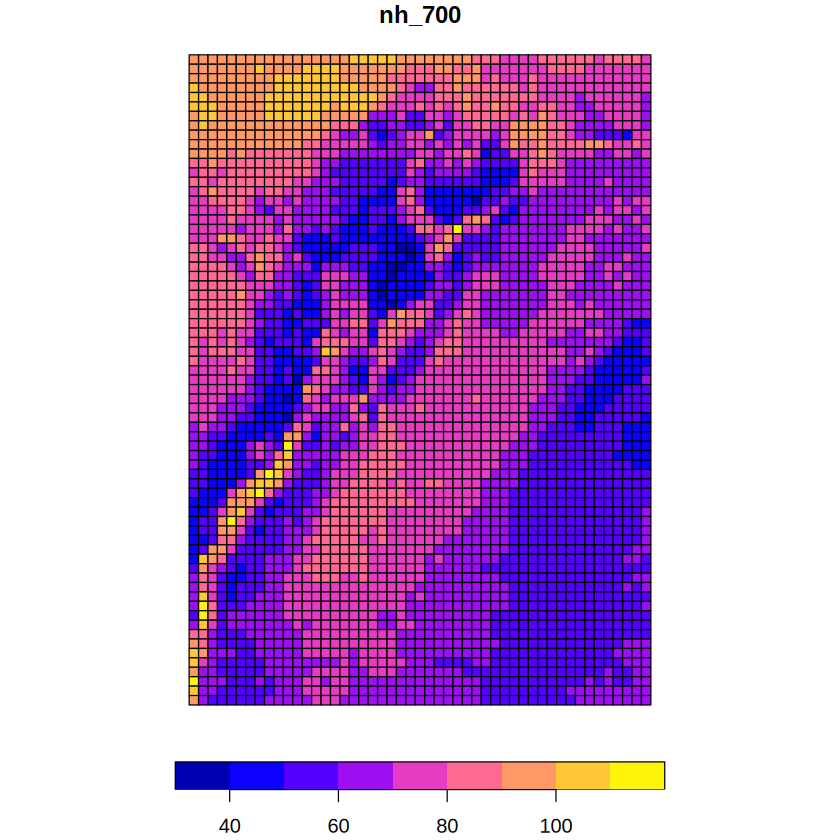

In [27]:
# ============================================================
# BLOQUE 12 — CREAR SF Y STARS DE VIENTO NO HURACANADO
# ============================================================

sf_nh <- sf1 %>%
  left_join(nhrl, by = "cellindexlr")

sf_nh

names(sf_nh)

head(sf_nh, 1)
tail(sf_nh, 1)

# Mapa de ejemplo: nh_700
plot(sf_nh[, "nh_700"], key.pos = 1, reset = FALSE)

# Convertir a stars
st_nh <- st_as_stars(sf_nh)

st_nh

names(st_nh)

In [28]:
# ============================================================
# BLOQUE 13 — LEER TIF DE VIENTO HURACANADO
# ============================================================

h_files <- list.files(
  path,
  pattern = "\\.tif$",
  full.names = TRUE,
  recursive = TRUE
)

# En hazard_curves se esperan:
# st1_cellindexlr.tif y st22_h_10.tif hasta st32_h_7000.tif
h_files <- h_files[
  grepl("st1_cellindexlr\\.tif$|st2[2-9]_h_|st3[0-2]_h_", basename(h_files))
]

h_files <- str_sort(h_files, numeric = TRUE)

head(h_files)
tail(h_files)
length(h_files)

# Debe dar 12
stopifnot(length(h_files) == 12)

st_h <- read_stars(h_files, quiet = TRUE)

mynames_h <- names(st_h)

head(mynames_h)
tail(mynames_h)

# Limpiar nombres
mynames_h <- str_replace(mynames_h, "^\\d+_", "")
mynames_h <- str_replace(mynames_h, "\\.tif$", "")

st_h <- setNames(st_h, mynames_h)

st_h

names(st_h)

[1] "./data_heavy/hazard_curves//st1_cellindexlr.tif"
[2] "./data_heavy/hazard_curves//st22_h_10.tif"      
[3] "./data_heavy/hazard_curves//st23_h_20.tif"      
[4] "./data_heavy/hazard_curves//st24_h_50.tif"      
[5] "./data_heavy/hazard_curves//st25_h_100.tif"     
[6] "./data_heavy/hazard_curves//st26_h_250.tif"

[1] "./data_heavy/hazard_curves//st27_h_500.tif" 
[2] "./data_heavy/hazard_curves//st28_h_700.tif" 
[3] "./data_heavy/hazard_curves//st29_h_1000.tif"
[4] "./data_heavy/hazard_curves//st30_h_1700.tif"
[5] "./data_heavy/hazard_curves//st31_h_3000.tif"
[6] "./data_heavy/hazard_curves//st32_h_7000.tif"

[1] 12

[1] "1_cellindexlr.tif" "22_h_10.tif"       "23_h_20.tif"      
[4] "24_h_50.tif"       "25_h_100.tif"      "26_h_250.tif"

[1] "27_h_500.tif"  "28_h_700.tif"  "29_h_1000.tif" "30_h_1700.tif"
[5] "31_h_3000.tif" "32_h_7000.tif"

stars object with 2 dimensions and 12 attributes
attribute(s):
                  Min.   1st Qu.     Median       Mean    3rd Qu.       Max.
cellindexlr   1.000000 846.00000 1691.00000 1691.00000 2536.00000 3381.00000
h_10          9.657264  15.60407   23.24976   30.49505   41.01136   84.59554
h_20         12.285217  22.10538   30.73002   42.99571   62.58664  134.10271
h_50         16.887383  27.95969   44.80460   61.98091   86.10312  188.30650
h_100        21.482809  33.50370   59.56685   76.71314  110.83393  217.23434
h_250        24.047953  42.12089   67.86799   94.92491  150.90559  262.40466
h_500        26.153105  50.09246   75.44077  108.12435  174.92483  302.71555
h_700        27.240479  54.71663   78.70475  114.44337  182.41410  324.46051
h_1000       28.442543  59.71330   82.73916  121.15120  190.39574  349.21902
h_1700       30.329725  62.42528   89.77281  131.28288  202.57220  389.59143
h_3000       32.488724  65.18401   96.70774  142.38969  215.88116  437.99152
h_7000       

[1] "cellindexlr" "h_10"        "h_20"        "h_50"        "h_100"      
 [6] "h_250"       "h_500"       "h_700"       "h_1000"      "h_1700"     
[11] "h_3000"      "h_7000"

stars object with 1 dimensions and 12 attributes
attribute(s):
                  Min.   1st Qu.     Median       Mean    3rd Qu.       Max.
cellindexlr   1.000000 846.00000 1691.00000 1691.00000 2536.00000 3381.00000
h_10          9.657264  15.60407   23.24976   30.49505   41.01136   84.59554
h_20         12.285217  22.10538   30.73002   42.99571   62.58664  134.10271
h_50         16.887383  27.95969   44.80460   61.98091   86.10312  188.30650
h_100        21.482809  33.50370   59.56685   76.71314  110.83393  217.23434
h_250        24.047953  42.12089   67.86799   94.92491  150.90559  262.40466
h_500        26.153105  50.09246   75.44077  108.12435  174.92483  302.71555
h_700        27.240479  54.71663   78.70475  114.44337  182.41410  324.46051
h_1000       28.442543  59.71330   82.73916  121.15120  190.39574  349.21902
h_1700       30.329725  62.42528   89.77281  131.28288  202.57220  389.59143
h_3000       32.488724  65.18401   96.70774  142.38969  215.88116  437.99152
h_7000       

ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

,cellindexlr,h_10,h_20,h_50,h_100,h_250,h_500,h_700,h_1000,h_1700,h_3000,h_7000,geometry
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<POLYGON [°]>
1,1,68.47093,91.80773,135.3448,171.5632,195.1727,215.1678,225.6001,237.2115,255.6010,276.8677,312.1155,"POLYGON ((-79.1 12.5, -78.8..."
2,2,68.58443,92.01710,135.7074,171.4681,193.8547,212.9895,222.9478,234.0130,251.4990,271.7078,305.6339,"POLYGON ((-78.85 12.5, -78...."
3,3,68.76575,92.35615,136.3943,171.7126,193.7527,212.5089,222.2578,233.0808,250.1652,269.9935,303.6305,"POLYGON ((-78.6 12.5, -78.3..."
4,4,68.90208,92.57769,136.8144,171.8713,193.7814,212.2229,221.8297,232.4885,249.3008,268.7823,301.8512,"POLYGON ((-78.35 12.5, -78...."
5,5,68.93599,92.61635,136.8426,171.8625,193.7243,212.0914,221.6260,232.2042,248.8830,268.0656,299.4638,"POLYGON ((-78.1 12.5, -77.8..."
6,6,68.92827,92.52505,136.5486,171.7202,193.5764,211.9407,221.4796,232.0611,248.7461,267.9371,299.3519,"POLYGON ((-77.85 12.5, -77...."
7,7,68.84084,92.23818,135.7941,171.3774,193.4134,212.1663,221.9144,232.7374,249.8232,269.5042,301.7819,"POLYGON ((-77.6 12.5, -77.3..."
8,8,68.65591,91.89215,135.0937,171.1369,193.6052,212.5893,222.4649,233.4349,250.7640,270.7427,303.5460,"POLYGON ((-77.35 12.5, -77...."
9,9,68.42961,91.55302,134.5247,170.9932,193.7937,213.0403,223.0611,234.1985,251.8052,272.1206,305.5126,"POLYGON ((-77.1 12.5, -76.8..."


[1] "cellindexlr" "h_10"        "h_20"        "h_50"        "h_100"      
 [6] "h_250"       "h_500"       "h_700"       "h_1000"      "h_1700"     
[11] "h_3000"      "h_7000"      "geometry"

ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

,cellindexlr,h_10,h_20,h_50,h_100,h_250,h_500,h_700,h_1000,h_1700,h_3000,h_7000,geometry
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<POLYGON [°]>
1,1,68.47093,91.80773,135.3448,171.5632,195.1727,215.1678,225.6001,237.2115,255.601,276.8677,312.1155,"POLYGON ((-79.1 12.5, -78.8..."


ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

,cellindexlr,h_10,h_20,h_50,h_100,h_250,h_500,h_700,h_1000,h_1700,h_3000,h_7000,geometry
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<POLYGON [°]>
3381,3381,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,"POLYGON ((-67.1 -4.5, -66.8..."


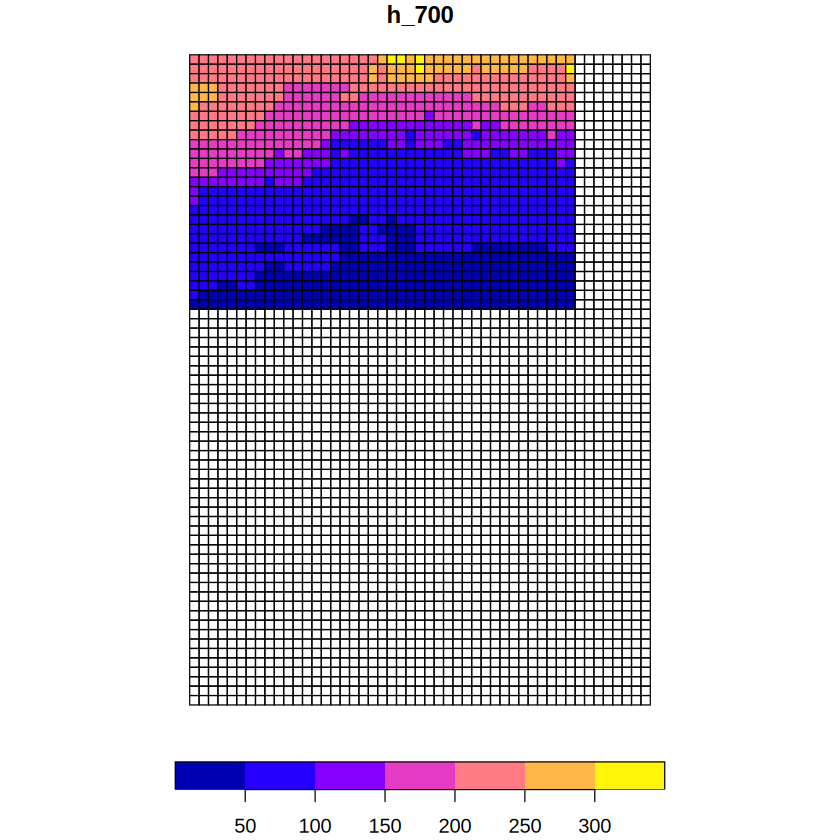

In [29]:
# ============================================================
# BLOQUE 14 — CONVERTIR VIENTO HURACANADO A SF
# ============================================================

st_h.stnoxy <- st_xy2sfc(
  st_h,
  as_points = FALSE,
  na.rm = TRUE
)

st_h.stnoxy

sf_h <- st_as_sf(st_h.stnoxy)

sf_h

names(sf_h)

head(sf_h, 1)
tail(sf_h, 1)

# Mapa de ejemplo: h_700
plot(sf_h[, "h_700"], key.pos = 1, reset = FALSE)

In [30]:
# ============================================================
# BLOQUE 15 — INTEGRAR NH + H + COLUMNAS VACÍAS C_
# ============================================================

df_nh_h <- sf_nh %>%
  st_drop_geometry() %>%
  select(-any_of("fg10_2017-01-01")) %>%
  left_join(
    sf_h %>%
      st_drop_geometry(),
    by = "cellindexlr"
  )

colnames(df_nh_h)

head(df_nh_h)

# Periodos de retorno que se van a consultar
mri_c <- c(10,20,50,100,250,500,700,1000,1700,3000,7000)

# Agregar columnas vacías para la combinación
for (mri in mri_c) {
  df_nh_h[[paste0("c_", mri)]] <- NA_real_
}

colnames(df_nh_h)

# Crear sf completo: no huracanado + huracanado + combinado vacío
sf_nh_h_c <- st_sf(
  df_nh_h,
  geometry = st_geometry(sf_nh)
)

sf_nh_h_c

colnames(sf_nh_h_c)

head(sf_nh_h_c)

[1] "cellindexlr" "nh_10"       "nh_20"       "nh_50"       "nh_100"     
 [6] "nh_250"      "nh_500"      "nh_700"      "nh_1000"     "nh_1700"    
[11] "nh_3000"     "nh_7000"     "h_10"        "h_20"        "h_50"       
[16] "h_100"       "h_250"       "h_500"       "h_700"       "h_1000"     
[21] "h_1700"      "h_3000"      "h_7000"

,cellindexlr,nh_10,nh_20,nh_50,nh_100,nh_250,nh_500,nh_700,nh_1000,nh_1700,⋯,h_20,h_50,h_100,h_250,h_500,h_700,h_1000,h_1700,h_3000,h_7000
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,75.72014,78.28825,81.68854,84.25276,87.65665,90.21695,91.47602,92.78860,94.75805,⋯,91.80773,135.3448,171.5632,195.1727,215.1678,225.6001,237.2115,255.6010,276.8677,312.1155
2,2,76.46347,78.91182,82.18571,84.66843,87.91439,90.40638,91.60661,92.86180,94.76200,⋯,92.01710,135.7074,171.4681,193.8547,212.9895,222.9478,234.0130,251.4990,271.7078,305.6339
3,3,77.62283,80.22663,83.68861,86.29951,89.75322,92.37109,93.64076,94.95989,96.96049,⋯,92.35615,136.3943,171.7126,193.7527,212.5089,222.2578,233.0808,250.1652,269.9935,303.6305
4,4,78.37462,80.91716,84.32186,86.87185,90.26838,92.82592,94.05573,95.39945,97.35954,⋯,92.57769,136.8144,171.8713,193.7814,212.2229,221.8297,232.4885,249.3008,268.7823,301.8512
5,5,79.37354,81.99186,85.52263,88.15294,91.66611,94.31032,95.60011,96.93849,98.96194,⋯,92.61635,136.8426,171.8625,193.7243,212.0914,221.6260,232.2042,248.8830,268.0656,299.4638
6,6,80.05098,82.69864,86.15614,88.78780,92.25871,94.87477,96.14925,97.51714,99.52656,⋯,92.52505,136.5486,171.7202,193.5764,211.9407,221.4796,232.0611,248.7461,267.9371,299.3519


[1] "cellindexlr" "nh_10"       "nh_20"       "nh_50"       "nh_100"     
 [6] "nh_250"      "nh_500"      "nh_700"      "nh_1000"     "nh_1700"    
[11] "nh_3000"     "nh_7000"     "h_10"        "h_20"        "h_50"       
[16] "h_100"       "h_250"       "h_500"       "h_700"       "h_1000"     
[21] "h_1700"      "h_3000"      "h_7000"      "c_10"        "c_20"       
[26] "c_50"        "c_100"       "c_250"       "c_500"       "c_700"      
[31] "c_1000"      "c_1700"      "c_3000"      "c_7000"

ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

cellindexlr nh_10    nh_20    nh_50    nh_100   nh_250    nh_500   
1     1          75.72014 78.28825 81.68854 84.25276  87.65665  90.21695
2     2          76.46347 78.91182 82.18571 84.66843  87.91439  90.40638
3     3          77.62283 80.22663 83.68861 86.29951  89.75322  92.37109
4     4          78.37462 80.91716 84.32186 86.87185  90.26838  92.82592
5     5          79.37354 81.99186 85.52263 88.15294  91.66611  94.31032
6     6          80.05098 82.69864 86.15614 88.78780  92.25871  94.87477
7     7          80.56784 83.08279 86.46334 88.97281  92.35583  94.88001
8     8          81.32401 83.83072 87.15182 89.68132  92.97866  95.52521
9     9          82.18675 84.71093 88.00640 90.55442  93.86172  96.39080
10   10          82.54443 84.97964 88.26406 90.73376  93.97091  96.46839
11   11          83.33411 85.76691 88.96640 91.43239  94.65228  97.06368
12   12          83.42193 85.69107 88.69416 90.94163  93.94448  96.23340
13   13          84.26002 86.67363 89.84365 92.25695  95.44828  97.84105
14   14          84.26608 86.56999 89.60264 91.87789  94.90747  97.21206
15   15          83.88174 86.09759 89.02403 91.27084  94.20079  96.43583
16   16          83.89531 86.23447 89.31899 91.65155  94.72641  97.02824
17   17          84.01241 86.42179 89.56408 91.91613  95.05154  97.45685
18   18          84.82064 87.33175 90.64341 93.12837  96.45671  98.93489
19   19          86.89796 89.85262 93.75970 96.71273 100.61651 103.56787
20   20          85.84771 88.79149 92.68317 95.62460  99.51172 102.45068
21   21          83.71440 86.49455 90.14710 92.91783  96.60687  99.38082
22   22          83.39254 86.21918 89.94927 92.79580  96.54916  99.37889
23   23          80.98314 83.59631 86.98064 89.59351  92.97814  95.59071
24   24          80.36643 82.92663 86.35830 88.91967  92.35014  94.91269
25   25          80.44011 83.07799 86.61802 89.27233  92.78786  95.45785
26   26          80.66950 83.44763 87.09694 89.87701  93.56325  96.33526
27   27          79.75751 82.49956 86.09305 88.83615  92.46414  95.18577
28   28          78.62933 81.30654 84.83755 87.52831  91.03944  93.73802
29   29          79.00343 81.62424 85.01705 87.63587  91.03063  93.64747
30   30          77.42768 79.86070 83.09065 85.56388  88.79077  91.23951
⋮    ⋮           ⋮        ⋮        ⋮        ⋮        ⋮         ⋮        
3352 3352        51.37499 53.75058 56.88455 59.27661 62.43038  64.80016 
3353 3353        51.53431 53.84591 56.91515 59.25767 62.34031  64.66997 
3354 3354        51.75307 54.23513 57.53157 59.98445 63.29546  65.77823 
3355 3355        51.41464 53.81608 56.98502 59.43007 62.61947  64.99801 
3356 3356        53.02313 55.75300 59.33529 62.01735 65.62532  68.32992 
3357 3357        52.46459 54.93012 58.23576 60.73047 63.99439  66.51830 
3358 3358        51.96362 54.48204 57.76435 60.25231 63.55248  66.00805 
3359 3359        51.34986 53.73888 56.88701 59.29179 62.46040  64.83755 
3360 3360        51.13341 53.57058 56.75795 59.16613 62.37552  64.78540 
3361 3361        50.05974 52.32968 55.29533 57.54810 60.51594  62.75264 
3362 3362        49.50170 51.63806 54.46621 56.60413 59.43032  61.56981 
3363 3363        48.48268 50.56472 53.30956 55.39625 58.12660  60.21822 
3364 3364        47.80392 49.75663 52.33511 54.27908 56.84562  58.79911 
3365 3365        47.20551 49.05584 51.56464 53.43276 55.88111  57.76489 
3366 3366        46.84582 48.64677 50.96500 52.77645 55.11490  56.89929 
3367 3367        47.15368 48.98703 51.47995 53.32587 55.77132  57.63372 
3368 3368        47.04085 48.94120 51.48081 53.37234 55.86073  57.76707 
3369 3369        47.14763 49.06500 51.64654 53.57694 56.09567  58.01169 
3370 3370        47.27154 49.13137 51.63483 53.51184 55.95359  57.84567 
3371 3371        47.43481 49.23357 51.64335 53.45758 55.83585  57.66437 
3372 3372        48.46307 50.25309 52.64792 54.45247 56.81997  58.63805 
3373 3373        48.88163 50.69033 53.01233 54.82794 57.18848  58.95773 
3374 3374        49.73290 51.68133 54.24294 56.18166 58.76245  

[1] "cellindexlr" "nh_10"       "nh_20"       "nh_50"       "nh_100"     
 [6] "nh_250"      "nh_500"      "nh_700"      "nh_1000"     "nh_1700"    
[11] "nh_3000"     "nh_7000"     "h_10"        "h_20"        "h_50"       
[16] "h_100"       "h_250"       "h_500"       "h_700"       "h_1000"     
[21] "h_1700"      "h_3000"      "h_7000"      "c_10"        "c_20"       
[26] "c_50"        "c_100"       "c_250"       "c_500"       "c_700"      
[31] "c_1000"      "c_1700"      "c_3000"      "c_7000"      "geometry"

ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

cellindexlr nh_10    nh_20    nh_50    nh_100   nh_250   nh_500   nh_700  
1 1           75.72014 78.28825 81.68854 84.25276 87.65665 90.21695 91.47602
2 2           76.46347 78.91182 82.18571 84.66843 87.91439 90.40638 91.60661
3 3           77.62283 80.22663 83.68861 86.29951 89.75322 92.37109 93.64076
4 4           78.37462 80.91716 84.32186 86.87185 90.26838 92.82592 94.05573
5 5           79.37354 81.99186 85.52263 88.15294 91.66611 94.31032 95.60011
6 6           80.05098 82.69864 86.15614 88.78780 92.25871 94.87477 96.14925
  nh_1000  nh_1700  geometry                       ⋯ c_50 c_100 c_250 c_500
1 92.78860 94.75805 POLYGON ((-79.225 12.625, -... ⋯ NA   NA    NA    NA   
2 92.86180 94.76200 POLYGON ((-78.975 12.625, -... ⋯ NA   NA    NA    NA   
3 94.95989 96.96049 POLYGON ((-78.725 12.625, -... ⋯ NA   NA    NA    NA   
4 95.39945 97.35954 POLYGON ((-78.475 12.625, -... ⋯ NA   NA    NA    NA   
5 96.93849 98.96194 POLYGON ((-78.225 12.625, -... ⋯ NA   NA    NA    NA   
6 97.51714 99.52656 POLYGON ((-77.975 12.625, -... ⋯ NA   NA    NA    NA   
  c_700 c_1000 c_1700 c_3000 c_7000 geometry                      
1 NA    NA     NA     NA     NA     POLYGON ((-79.225 12.625, -...
2 NA    NA     NA     NA     NA     POLYGON ((-78.975 12.625, -...
3 NA    NA     NA     NA     NA     POLYGON ((-78.725 12.625, -...
4 NA    NA     NA     NA     NA     POLYGON ((-78.475 12.625, -...
5 NA    NA     NA     NA     NA     POLYGON ((-78.225 12.625, -...
6 NA    NA     NA     NA     NA     POLYGON ((-77.975 12.625, -...

In [31]:
# ============================================================
# BLOQUE 16 — CREAR STARS CON 34 ATRIBUTOS
# ============================================================

st_nh_h_c <- st_as_stars(sf_nh_h_c)

st_nh_h_c

names(st_nh_h_c)

# Verificar posiciones esperadas:
# 1 = cellindexlr
# 2:12 = nh_*
# 13:23 = h_*
# 24:34 = c_* vacíos

names(st_nh_h_c[2:12])
names(st_nh_h_c[13:23])
names(st_nh_h_c[24:34])

# Consolidar los 34 atributos en una dimensión llamada attributes
st_nh_h_c_merged <- merge(st_nh_h_c)

st_nh_h_c_merged

st_dimensions(st_nh_h_c_merged)

names(st_nh_h_c_merged)

stars object with 1 dimensions and 34 attributes
attribute(s):
                  Min.   1st Qu.     Median       Mean    3rd Qu.       Max.
cellindexlr   1.000000 846.00000 1691.00000 1691.00000 2536.00000 3381.00000
nh_10        30.455574  47.29626   54.97847   56.00259   62.59727   93.30645
nh_20        31.460815  48.98871   57.36158   58.11512   65.05826   97.62114
nh_50        32.774192  51.44771   60.47336   60.90802   68.32351  103.31804
nh_100       33.778357  53.16982   62.71490   63.02051   70.73157  107.63102
nh_250       35.054548  55.53590   65.66963   65.81263   73.79312  113.32841
nh_500       36.060672  57.32040   67.83204   67.92533   76.13768  117.64088
nh_700       36.552354  58.16289   68.82161   68.95081   77.35256  119.73103
nh_1000      36.921115  59.11357   69.89242   70.03859   78.62801  121.93811
nh_1700      37.616289  60.48772   71.47005   71.65534   80.40082  125.24810
nh_3000      38.121564  61.89749   73.10100   73.38663   82.45458  128.78034
nh_7000      

[1] "cellindexlr" "nh_10"       "nh_20"       "nh_50"       "nh_100"     
 [6] "nh_250"      "nh_500"      "nh_700"      "nh_1000"     "nh_1700"    
[11] "nh_3000"     "nh_7000"     "h_10"        "h_20"        "h_50"       
[16] "h_100"       "h_250"       "h_500"       "h_700"       "h_1000"     
[21] "h_1700"      "h_3000"      "h_7000"      "c_10"        "c_20"       
[26] "c_50"        "c_100"       "c_250"       "c_500"       "c_700"      
[31] "c_1000"      "c_1700"      "c_3000"      "c_7000"

[1] "nh_10"   "nh_20"   "nh_50"   "nh_100"  "nh_250"  "nh_500"  "nh_700" 
 [8] "nh_1000" "nh_1700" "nh_3000" "nh_7000"

[1] "h_10"   "h_20"   "h_50"   "h_100"  "h_250"  "h_500"  "h_700"  "h_1000"
 [9] "h_1700" "h_3000" "h_7000"

[1] "c_10"   "c_20"   "c_50"   "c_100"  "c_250"  "c_500"  "c_700"  "c_1000"
 [9] "c_1700" "c_3000" "c_7000"

stars object with 2 dimensions and 1 attribute
attribute(s):
                                Min.  1st Qu.   Median     Mean 3rd Qu. Max.
cellindexlr.nh_10.nh_20.nh_...     1 54.78237 66.99432 178.0459 82.9867 3381
                                 NA's
cellindexlr.nh_10.nh_20.nh_...  62205
dimension(s):
           from   to point
geometry      1 3381 FALSE
attributes    1   34    NA
                                                                  values
geometry   POLYGON ((-79.225 12.625,...,...,POLYGON ((-67.225 -4.375,...
attributes                                        cellindexlr,...,c_7000

           from   to point
geometry      1 3381 FALSE
attributes    1   34    NA
                                                                  values
geometry   POLYGON ((-79.225 12.625,...,...,POLYGON ((-67.225 -4.375,...
attributes                                        cellindexlr,...,c_7000

[1] "cellindexlr.nh_10.nh_20.nh_50.nh_100.nh_250.nh_500.nh_700.nh_1000.nh_1700.nh_3000.nh_7000.h_10.h_20.h_50.h_100.h_250.h_500.h_700.h_1000.h_1700.h_3000.h_7000.c_10.c_20.c_50.c_100.c_250.c_500.c_700.c_1000.c_1700.c_3000.c_7000"

In [32]:
# ============================================================
# BLOQUE 17 — EJECUTAR COMBINACIÓN CELDA A CELDA
# ============================================================

mycuenta <- 0

combined_st <- st_apply(
  X = st_nh_h_c_merged,
  MARGIN = "geometry",
  FUN = combined_columns_st_apply,
  
  bands_rl_h = c(13:23),
  mri_h = c(10,20,50,100,250,500,700,1000,1700,3000,7000),
  
  bands_rl_nh = c(2:12),
  mri_nh = c(10,20,50,100,250,500,700,1000,1700,3000,7000),
  
  mri_c = mri_c
)

combined_st

st_dimensions(combined_st)

names(combined_st)

[1] "contar: 1"
[1] "mycuenta: 1"
[1] "contar: 3381"
[1] "mycuenta: 3381"


stars object with 2 dimensions and 1 attribute
attribute(s):
                                    Min.  1st Qu.   Median     Mean  3rd Qu.
cellindexlr.nh_10.nh_20.nh_...  30.59398 56.55861 66.47847 79.21835 78.40982
                                    Max.
cellindexlr.nh_10.nh_20.nh_...  478.4576
dimension(s):
                          from   to point
combined_columns_st_apply    1   11    NA
geometry                     1 3381 FALSE
                                                                                 values
combined_columns_st_apply                                                          NULL
geometry                  POLYGON ((-79.225 12.625,...,...,POLYGON ((-67.225 -4.375,...

                          from   to point
combined_columns_st_apply    1   11    NA
geometry                     1 3381 FALSE
                                                                                 values
combined_columns_st_apply                                                          NULL
geometry                  POLYGON ((-79.225 12.625,...,...,POLYGON ((-67.225 -4.375,...

[1] "cellindexlr.nh_10.nh_20.nh_50.nh_100.nh_250.nh_500.nh_700.nh_1000.nh_1700.nh_3000.nh_7000.h_10.h_20.h_50.h_100.h_250.h_500.h_700.h_1000.h_1700.h_3000.h_7000.c_10.c_20.c_50.c_100.c_250.c_500.c_700.c_1000.c_1700.c_3000.c_7000"

In [33]:
# ============================================================
# BLOQUE 18 — ORGANIZAR RESULTADO FINAL
# ============================================================

# Renombrar dimensión generada por st_apply
combined_st <- st_set_dimensions(
  combined_st,
  "combined_columns_st_apply",
  names = "c_mri"
)

# Asignar valores de los periodos de retorno
combined_st <- st_set_dimensions(
  combined_st,
  "c_mri",
  values = paste0("c_", mri_c)
)

# Renombrar atributo
names(combined_st) <- "rafaga_viento"

combined_st

# Transponer para dejar geometry primero y c_mri después
combined_st <- aperm(combined_st, c(2, 1))

combined_st

st_dimensions(combined_st)

stars object with 2 dimensions and 1 attribute
attribute(s):
                   Min.  1st Qu.   Median     Mean  3rd Qu.     Max.
rafaga_viento  30.59398 56.55861 66.47847 79.21835 78.40982 478.4576
dimension(s):
         from   to point
c_mri       1   11    NA
geometry    1 3381 FALSE
                                                                values
c_mri                                                  c_10,...,c_7000
geometry POLYGON ((-79.225 12.625,...,...,POLYGON ((-67.225 -4.375,...

stars object with 2 dimensions and 1 attribute
attribute(s):
                   Min.  1st Qu.   Median     Mean  3rd Qu.     Max.
rafaga_viento  30.59398 56.55861 66.47847 79.21835 78.40982 478.4576
dimension(s):
         from   to point
geometry    1 3381 FALSE
c_mri       1   11    NA
                                                                values
geometry POLYGON ((-79.225 12.625,...,...,POLYGON ((-67.225 -4.375,...
c_mri                                                  c_10,...,c_7000

         from   to point
geometry    1 3381 FALSE
c_mri       1   11    NA
                                                                values
geometry POLYGON ((-79.225 12.625,...,...,POLYGON ((-67.225 -4.375,...
c_mri                                                  c_10,...,c_7000

ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

,c_mri,rafaga_viento,geometry
,<fct>,<dbl>,<POLYGON>
1,c_10,80.73873,"POLYGON ((-79.225 12.625, -..."
2,c_10,81.19895,"POLYGON ((-78.975 12.625, -..."
3,c_10,82.40477,"POLYGON ((-78.725 12.625, -..."
4,c_10,82.96593,"POLYGON ((-78.475 12.625, -..."
5,c_10,83.88777,"POLYGON ((-78.225 12.625, -..."
6,c_10,84.40800,"POLYGON ((-77.975 12.625, -..."
7,c_10,84.64167,"POLYGON ((-77.725 12.625, -..."
8,c_10,85.16248,"POLYGON ((-77.475 12.625, -..."
9,c_10,85.80184,"POLYGON ((-77.225 12.625, -..."


[1] "c_mri"         "rafaga_viento" "geometry"

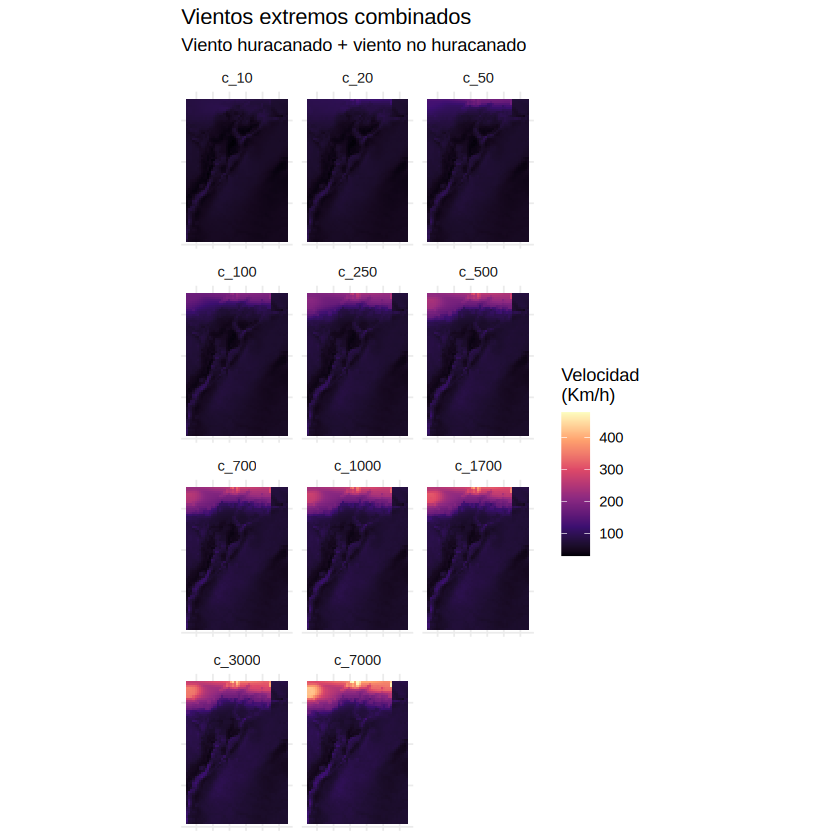

In [34]:
# ============================================================
# BLOQUE 19 — MAPA FACETADO DE TODOS LOS PERIODOS
# ============================================================

sf_combined <- st_as_sf(
  combined_st,
  as_points = FALSE,
  merge = FALSE,
  long = TRUE
)

sf_combined

colnames(sf_combined)

ggplot(data = sf_combined) +
  geom_sf(aes(fill = rafaga_viento), color = NA) +
  facet_wrap(~ c_mri, ncol = 3) +
  scale_fill_viridis_c(
    name = "Velocidad\n(Km/h)",
    option = "magma"
  ) +
  theme_minimal() +
  theme(
    axis.text = element_blank(),
    axis.title = element_blank()
  ) +
  labs(
    title = "Vientos extremos combinados",
    subtitle = "Viento huracanado + viento no huracanado"
  )

In [35]:
# ============================================================
# BLOQUE 20 — RESULTADO EN FORMATO ANCHO
# ============================================================

sf_combined_wide <- st_as_sf(
  combined_st,
  as_points = FALSE,
  merge = FALSE,
  long = FALSE
)

names(sf_combined_wide)

head(sf_combined_wide)

# Convertir de nuevo a stars con 11 atributos
combined_st_attrs <- st_as_stars(sf_combined_wide)

combined_st_attrs

names(combined_st_attrs)

[1] "c_10"     "c_20"     "c_50"     "c_100"    "c_250"    "c_500"   
 [7] "c_700"    "c_1000"   "c_1700"   "c_3000"   "c_7000"   "geometry"

ERROR while rich displaying an object: Error in loadNamespace(x): there is no package called ‘geojsonio’

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = 

,c_10,c_20,c_50,c_100,c_250,c_500,c_700,c_1000,c_1700,c_3000,c_7000,geometry
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<POLYGON>
1,80.73873,93.09832,135.5677,171.5835,195.3465,215.2692,225.6901,237.3066,255.7378,276.9357,312.1155,"POLYGON ((-79.225 12.625, -..."
2,81.19895,93.27719,135.8558,171.4787,193.9378,212.9942,222.9642,234.0211,251.6503,271.8448,305.6339,"POLYGON ((-78.975 12.625, -..."
3,82.40477,94.12984,136.6104,171.7206,193.8860,212.6534,222.3395,233.1262,250.2706,269.9971,303.6305,"POLYGON ((-78.725 12.625, -..."
4,82.96593,94.42348,136.9125,171.8758,193.9003,212.3434,221.8781,232.6106,249.4460,268.8909,301.8512,"POLYGON ((-78.475 12.625, -..."
5,83.88777,94.99627,136.9271,171.8671,193.8688,212.1546,221.7123,232.2963,248.9334,268.1334,299.4638,"POLYGON ((-78.225 12.625, -..."
6,84.40800,95.14756,136.7445,171.7272,193.7742,211.9665,221.5768,232.0965,248.8452,267.9703,299.3519,"POLYGON ((-77.975 12.625, -..."


stars object with 1 dimensions and 11 attributes
attribute(s):
            Min.  1st Qu.   Median      Mean  3rd Qu.      Max.
c_10    30.59398 47.32365 55.10004  56.38038 62.64694  93.66784
c_20    31.81944 49.29675 57.76510  59.44482 65.48180 134.17278
c_50    33.26477 51.80405 60.92374  65.05527 68.97079 188.41439
c_100   34.55717 53.77472 63.37895  70.11184 71.93368 217.44337
c_250   35.91330 56.43309 66.34858  76.84945 75.85305 262.64536
c_500   37.37326 58.55547 68.73313  81.93755 78.79750 302.82607
c_700   37.91354 59.53131 69.73639  84.43080 80.10125 324.56443
c_1000  38.39220 60.65315 70.92808  87.15010 81.76703 349.32248
c_1700  38.95457 62.15541 72.80064  91.28766 83.97476 389.73707
c_3000  39.69297 63.81977 74.79913  95.86459 86.67222 437.99241
c_7000  40.43278 66.00681 77.46043 102.88945 90.49137 478.45761
dimension(s):
         from   to point
geometry    1 3381 FALSE
                                                                values
geometry POLYGON ((-79.225 12.625,

[1] "c_10"   "c_20"   "c_50"   "c_100"  "c_250"  "c_500"  "c_700"  "c_1000"
 [9] "c_1700" "c_3000" "c_7000"

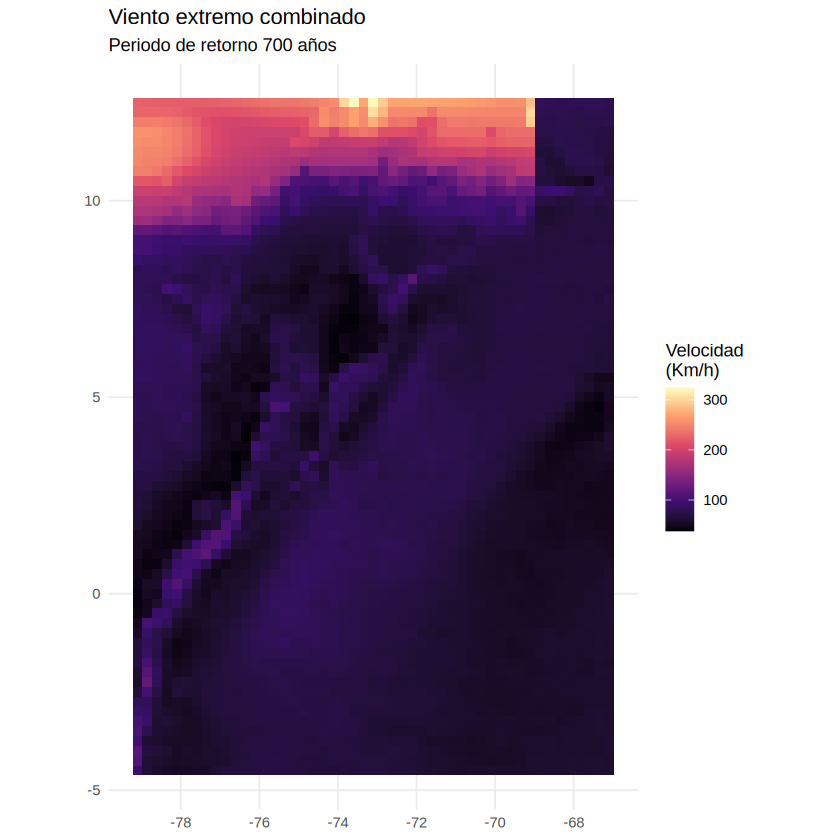

In [38]:
# ============================================================
# BLOQUE 21 — MAPA FINAL DE C_700
# ============================================================

ggplot() +
  geom_sf(data = sf_combined_wide, aes(fill = c_700), color = NA) +
  scale_fill_viridis_c(
    name = "Velocidad\n(Km/h)",
    option = "magma"
  ) +
  theme_minimal() +
  labs(
    title = "Viento extremo combinado",
    subtitle = "Periodo de retorno 700 años"
  )

In [39]:
# ============================================================
# BLOQUE 22 — EXPORTAR RESULTADO FINAL
# ============================================================

salida_gpkg <- "./data_heavy/vientos_combinados.gpkg"

st_write(
  sf_combined_wide,
  salida_gpkg,
  delete_dsn = TRUE
)

salida_gpkg

writing: substituting ENGCRS["Undefined Cartesian SRS with unknown unit"] for missing CRS



Deleting source `./data_heavy/vientos_combinados.gpkg' failed
Writing layer `vientos_combinados' to data source 
  `./data_heavy/vientos_combinados.gpkg' using driver `GPKG'
Writing 3381 features with 11 fields and geometry type Polygon.


[1] "./data_heavy/vientos_combinados.gpkg"